In [26]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
base_path = Path("..")

processed_path = base_path / "data" / "processed"
labels_path = processed_path / "labels.csv"

In [3]:
df = pd.read_csv(labels_path)

df.head()

,source_id,wet_path,room_size,wet_level,rate_hz,depth,room_size_norm,wet_level_norm,rate_hz_norm,depth_norm
0,Bridge_1-0,..\data\processed\wet\Bridge_1-0_v0.wav,0.374540,0.570429,3.793973,0.598658,0.374540,0.950714,0.731994,0.598658
1,Bridge_1-0,..\data\processed\wet\Bridge_1-0_v1.wav,0.156019,0.093597,0.761376,0.866176,0.156019,0.155995,0.058084,0.866176
2,Bridge_1-0,..\data\processed\wet\Bridge_1-0_v2.wav,0.601115,0.424844,0.592630,0.969910,0.601115,0.708073,0.020584,0.969910
3,Bridge_1-0,..\data\processed\wet\Bridge_1-0_v3.wav,0.832443,0.127403,1.318212,0.183405,0.832443,0.212339,0.181825,0.183405
4,Bridge_1-0,..\data\processed\wet\Bridge_1-0_v4.wav,0.304242,0.314854,2.443753,0.291229,0.304242,0.524756,0.431945,0.291229


In [4]:
print("Shape:", df.shape)
print("Unique sources:", df["source_id"].nunique())
print("\nMissing values:")
print(df.isna().sum())

Shape: (3450, 10)
Unique sources: 690

Missing values:
source_id         0
wet_path          0
room_size         0
wet_level         0
rate_hz           0
depth             0
room_size_norm    0
wet_level_norm    0
rate_hz_norm      0
depth_norm        0
dtype: int64


In [5]:
target_cols = [
    "room_size",
    "wet_level",
    "rate_hz",
    "depth",
]

df[target_cols].describe()

,room_size,wet_level,rate_hz,depth
count,3450.000000,3450.000000,3450.000000,3450.000000
mean,0.496212,0.297606,2.732791,0.495777
std,0.287290,0.172901,1.300763,0.289438
min,0.000135,0.000136,0.500052,0.000031
25%,0.250968,0.145991,1.585720,0.246974
50%,0.495579,0.298991,2.707087,0.487670
75%,0.741502,0.445999,3.875882,0.748254
max,0.999414,0.599804,4.996433,0.999718


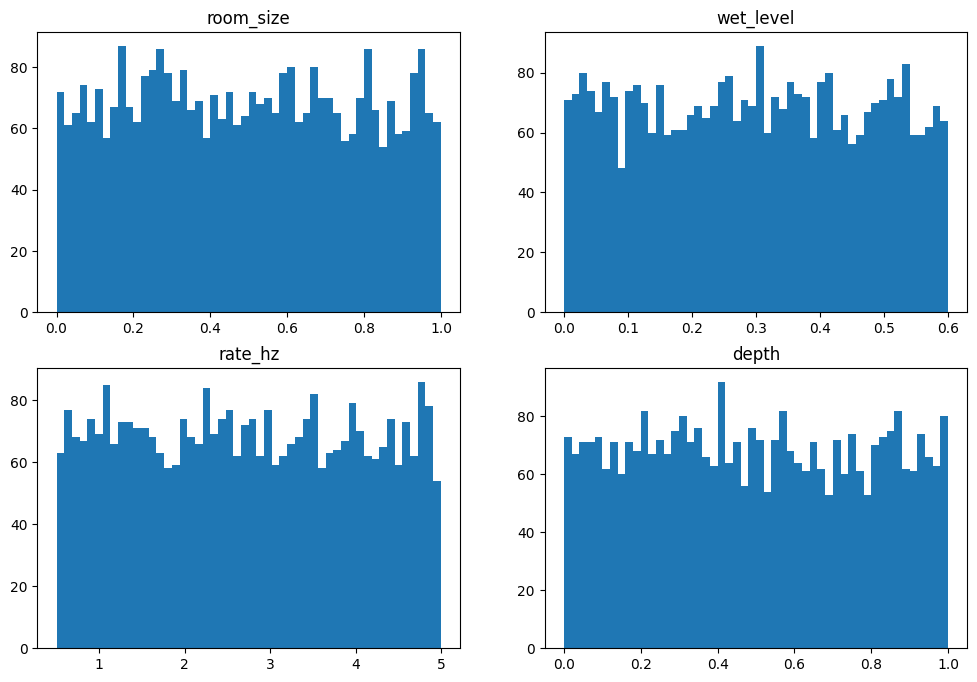

In [19]:

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, col in zip(axes.flatten(), target_cols):
    ax.hist(df[col], bins = 50)
    ax.set_title(col)
    
plt.show()

#### Подготовка данных

In [32]:
source_ids = df["source_id"].drop_duplicates()
source_ids.to_numpy()
len(source_ids)



690

In [33]:
train_source_ids, temp_source_ids = train_test_split(
    source_ids,
    test_size=0.3,
    random_state=42
)
len(train_source_ids), len(temp_source_ids)

(483, 207)

In [35]:
val_source_ids, test_source_ids = train_test_split(
    temp_source_ids,
    test_size=0.5,
    random_state=42
)
len(val_source_ids), len(test_source_ids)

(103, 104)

In [38]:
print(set(train_source_ids).intersection(set(temp_source_ids)))
print(set(val_source_ids).intersection(set(test_source_ids)))

set()
set()


In [42]:
train_df = df[df["source_id"].isin(train_source_ids)]
val_df = df[df["source_id"].isin(val_source_ids)]
test_df = df[df["source_id"].isin(test_source_ids)]
print(len(train_df), len(val_df), len(test_df))


2415 515 520


In [44]:
train_df["source_id"].nunique(), val_df["source_id"].nunique(), test_df["source_id"].nunique()

(483, 103, 104)